# Particles / IRR: Particle Distribution and Its Relationship with IRR

## Problem statement

A production line has reported inconsistent particle-contamination results. The process is inspected at three manufacturing stations:

- SUB30
- AOI20
- ICT40

The team needs to understand not only the average particle level, but also **where contamination is generated or accumulated** and whether it is associated with:
- manufacturing station;
- operator (A to D);
- shift (1 to 5);
- product line (Line_A or Line_B);
- particle size;
- particle type (Metallic or Non-metallic); and
- the quality response, IRR.

This is therefore a **multi-factor manufacturing problem**, not a single-variable comparison.

### Business impact

High particle contamination can increase rework, inspection effort, quality risk, and process instability. Metallic particles may also have a different risk profile from non-metallic particles, so **particle count alone is not sufficient**. The investigation evaluates both how many particles are detected and what types are present.

## Analytical approach

The investigation follows this engineering workflow:

Define -> Measure -> Validate data -> Structure the database -> Explore -> Drill down -> Test hypotheses -> Interpret -> Act

### Questions to answer

1. Which station has the highest particle burden?
2. Are station differences explained by operator, shift, product line, or particle type?
3. Are some operators consistently associated with higher particle metrics?
4. Is contamination worse on particular shifts?
5. Does either product line produce larger or more numerous particles?
6. Are metallic particles larger or associated with a higher contamination metric?
7. How does the particle-size distribution vary by type and product line?
8. Is particle_metric associated with IRR?
9. Which variables remain measurably associated after accounting for the other factors?

### Data architecture

The analysis reads `particle_irr_enriched.csv` as its source. Raw and transformed analytical data are stored in `particles_irr_analysis.db`.

# 1. Set up the analysis

SQLite serves as the dashboard's analytical data source. Python is used for statistical analysis and visualization, and the resulting summaries are written to SQL tables for use by the Streamlit dashboard.

In [1]:
from pathlib import Path
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

#Defining my folder

DATA_PATH = Path("particle_irr_enriched.csv")
DB_PATH = Path("particles_irr_analysis.db")
APP_PATH = Path("particles_irr_streamlit.py")
ALPHA = 0.05

print("Source CSV", DATA_PATH.resolve())
print("Database Path", DB_PATH.resolve())


Source CSV /Users/carlosferreira/Documents/Particles_Project_IRR/particle_irr_enriched.csv
Database Path /Users/carlosferreira/Documents/Particles_Project_IRR/particles_irr_analysis.db


# 2. Load the CSV and inspect the data

Review the dataset's shape, schema, missing values, duplicate rows, and category cardinality.

In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

display(df.head())

display(pd.DataFrame({
    "dtype:":df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
}))

display(df.describe(include="all").T)

print("Duplicate rows:", df.duplicated().sum())

Shape: (960, 10)


,sample_id,station,operator_id,shift,product_line,particle_type,particle_size_um,particle_count,particle_metric,irr
0,1,SUB30,A,1,Line_A,Metallic,50.59,12,21.77,91.44
1,2,SUB30,A,1,Line_A,Metallic,31.42,11,17.47,83.32
2,3,SUB30,A,1,Line_A,Metallic,47.86,13,22.65,91.42
3,4,SUB30,A,1,Line_A,Metallic,48.56,19,28.08,88.78
4,5,SUB30,A,1,Line_A,Non-metallic,37.13,8,13.86,81.78


,dtype:,missing,unique
sample_id,int64,0,960
station,str,0,3
operator_id,str,0,4
shift,int64,0,5
product_line,str,0,2
particle_type,str,0,2
particle_size_um,float64,0,872
particle_count,int64,0,36
particle_metric,float64,0,832
irr,float64,0,817


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sample_id,960.0,NaN,NaN,NaN,480.5,277.272429,1.0,240.75,480.5,720.25,960.0
station,960,3,SUB30,320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operator_id,960,4,A,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shift,960.0,NaN,NaN,NaN,3.0,1.414951,1.0,2.0,3.0,4.0,5.0
product_line,960,2,Line_A,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
particle_type,960,2,Metallic,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
particle_size_um,960.0,NaN,NaN,NaN,54.404198,14.608716,14.52,44.69,54.61,64.57,101.25
particle_count,960.0,NaN,NaN,NaN,23.689583,6.788592,5.0,19.0,24.0,28.0,41.0
particle_metric,960.0,NaN,NaN,NaN,31.422042,8.861283,8.68,25.1575,31.525,37.8125,54.33
irr,960.0,NaN,NaN,NaN,95.55124,7.860307,68.91,90.1975,95.44,101.145,118.65


Duplicate rows: 0


## 3. Create the database

Load the raw data into the bronze layer without transformations or cleaning.

In [3]:
with sqlite3.connect(DB_PATH) as con:
    df.to_sql("bronze_particles_irr", con, if_exists="replace", index=False)
    display(pd.read_sql_query("SELECT COUNT(*) AS row_loaded FROM bronze_particles_irr", con))

,row_loaded
0,960


# 4. Validate data quality

Before analysis, validate the dimensions that define the manufacturing problem:
- stations must be SUB30, AOI20, or ICT40;
- operators must be A to D;
- shifts must be 1 to 5;
- product lines must be Line_A or Line_B;
- particle types must be Metallic or Non-metallic;
- particle size, count, metric, and IRR must be numeric and non-null; and
- sample IDs should be unique.

In [4]:
checks = {
    "rows": len(df),
    "duplicate_sample_id": int(df["sample_id"].duplicated().sum()),
    "missing_total": int(df.isna().sum().sum()),
    "invalid_station": int((~df["station"].isin(["SUB30","AOI20","ICT40"])).sum()),
    "invalid_operator": int((~df["operator_id"].isin(list("ABCD"))).sum()),
    "invalid_shift": int((~df["shift"].isin([1,2,3,4,5])).sum()),
    "invalid_product": int((~df["product_line"].isin(["Line_A","Line_B"])).sum()),
    "invalid_particle_type": int((~df["particle_type"].isin(["Metallic","Non-metallic"])).sum())
}

display(pd.DataFrame.from_dict(checks, orient="index", columns=["value"]))

,value
rows,960
duplicate_sample_id,0
missing_total,0
invalid_station,0
invalid_operator,0
invalid_shift,0
invalid_product,0
invalid_particle_type,0


# 5. Prepare analytical SQL tables

The silver layer standardizes the schema and adds only derived fields with analytical meaning. A particle-size band supports dashboard filtering while the continuous `particle_size_um` value is preserved for histograms and statistical analysis.

In [5]:
silver_sql = """
DROP TABLE IF EXISTS silver_particles_irr;
CREATE TABLE silver_particles_irr AS
SELECT
    CAST(sample_id AS INTEGER) AS sample_id,
    TRIM(station) AS station,
    TRIM(operator_id) AS operator_id,
    CAST(shift AS INTEGER) AS shift,
    TRIM(product_line) AS product_line,
    TRIM(particle_type) AS particle_type,
    CAST(particle_size_um AS REAL) AS particle_size_um,
    CAST(particle_count AS INTEGER) AS particle_count,
    CAST(particle_metric AS REAL) AS particle_metric,
    CAST(irr AS REAL) AS irr,
    CASE
        WHEN particle_size_um < 40 THEN 'Small <40µm'
        WHEN particle_size_um < 60 THEN 'Medium 40–60µm'
        ELSE 'Large ≥60µm'
    END AS particle_size_band
FROM bronze_particles_irr
WHERE sample_id IS NOT NULL
  AND station IN ('SUB30','AOI20','ICT40')
  AND operator_id IN ('A','B','C','D')
  AND shift BETWEEN 1 AND 5
  AND product_line IN ('Line_A','Line_B')
  AND particle_type IN ('Metallic','Non-metallic')
  AND particle_size_um IS NOT NULL
  AND particle_count IS NOT NULL
  AND particle_metric IS NOT NULL
  AND irr IS NOT NULL;
"""

with sqlite3.connect(DB_PATH) as con:
    con.executescript(silver_sql)
    particles = pd.read_sql_query("SELECT * FROM silver_particles_irr ORDER BY sample_id", con)

print("Silver shape:", particles.shape)
display(particles.head())

Silver shape: (960, 11)


,sample_id,station,operator_id,shift,product_line,particle_type,particle_size_um,particle_count,particle_metric,irr,particle_size_band
0,1,SUB30,A,1,Line_A,Metallic,50.59,12,21.77,91.44,Medium 40–60µm
1,2,SUB30,A,1,Line_A,Metallic,31.42,11,17.47,83.32,Small <40µm
2,3,SUB30,A,1,Line_A,Metallic,47.86,13,22.65,91.42,Medium 40–60µm
3,4,SUB30,A,1,Line_A,Metallic,48.56,19,28.08,88.78,Medium 40–60µm
4,5,SUB30,A,1,Line_A,Non-metallic,37.13,8,13.86,81.78,Small <40µm


# 6. Data-quality findings

The data passes the structural checks required for the questions in this analysis, so the investigation can move from data quality to process diagnosis.

The database contains tables at different levels of detail because each engineering question needs a different view:
- station-level: where is contamination highest?
- station by operator: is an operator pattern consistent within a station?
- station by shift: is there a shift pattern?
- station by product: does product mix explain station differences?
- particle type and size: are metallic or larger particles associated with the metric?

# 7. Create summary tables

Each gold table has a defined level of detail and purpose:
- `gold_station_summary`: one row per station;
- `gold_station_operator_summary`: one row per station and operator;
- `gold_station_shift_summary`: one row per station and shift;
- `gold_station_product_summary`: one row per station and product line;
- `gold_particle_type_summary`: one row per particle type; and
- `gold_size_band_summary`: one row per particle-size band and particle type.

These tables are ready for the dashboard and remain traceable to the silver sample-level measurement table.

In [6]:
gold_sql = """
DROP TABLE IF EXISTS gold_station_summary;
CREATE TABLE gold_station_summary AS
SELECT station, COUNT(*) AS n,
       AVG(particle_count) AS avg_particle_count,
       AVG(particle_size_um) AS avg_particle_size_um,
       AVG(particle_metric) AS avg_particle_metric,
       AVG(irr) AS avg_irr
FROM silver_particles_irr GROUP BY station;

DROP TABLE IF EXISTS gold_station_operator_summary;
CREATE TABLE gold_station_operator_summary AS
SELECT station, operator_id, COUNT(*) AS n,
       AVG(particle_count) AS avg_particle_count,
       AVG(particle_size_um) AS avg_particle_size_um,
       AVG(particle_metric) AS avg_particle_metric,
       AVG(irr) AS avg_irr
FROM silver_particles_irr GROUP BY station, operator_id;

DROP TABLE IF EXISTS gold_station_shift_summary;
CREATE TABLE gold_station_shift_summary AS
SELECT station, shift, COUNT(*) AS n,
       AVG(particle_metric) AS avg_particle_metric,
       AVG(particle_size_um) AS avg_particle_size_um,
       AVG(irr) AS avg_irr
FROM silver_particles_irr GROUP BY station, shift;

DROP TABLE IF EXISTS gold_station_product_summary;
CREATE TABLE gold_station_product_summary AS
SELECT station, product_line, COUNT(*) AS n,
       AVG(particle_metric) AS avg_particle_metric,
       AVG(particle_size_um) AS avg_particle_size_um,
       AVG(irr) AS avg_irr
FROM silver_particles_irr GROUP BY station, product_line;

DROP TABLE IF EXISTS gold_particle_type_summary;
CREATE TABLE gold_particle_type_summary AS
SELECT particle_type, COUNT(*) AS n,
       AVG(particle_count) AS avg_particle_count,
       AVG(particle_size_um) AS avg_particle_size_um,
       AVG(particle_metric) AS avg_particle_metric,
       AVG(irr) AS avg_irr
FROM silver_particles_irr GROUP BY particle_type;

DROP TABLE IF EXISTS gold_size_band_summary;
CREATE TABLE gold_size_band_summary AS
SELECT particle_size_band, particle_type, COUNT(*) AS n,
       AVG(particle_metric) AS avg_particle_metric,
       AVG(irr) AS avg_irr
FROM silver_particles_irr GROUP BY particle_size_band, particle_type;
"""
with sqlite3.connect(DB_PATH) as con:
    con.executescript(gold_sql)
    station_summary = pd.read_sql_query("SELECT * FROM gold_station_summary ORDER BY avg_particle_metric DESC", con)
    station_operator = pd.read_sql_query("SELECT * FROM gold_station_operator_summary ORDER BY station, avg_particle_metric DESC", con)
    station_shift = pd.read_sql_query("SELECT * FROM gold_station_shift_summary ORDER BY station, shift", con)
    station_product = pd.read_sql_query("SELECT * FROM gold_station_product_summary ORDER BY station, product_line", con)

display(station_summary)

,station,n,avg_particle_count,avg_particle_size_um,avg_particle_metric,avg_irr
0,ICT40,320,30.171875,65.935250,39.357031,101.449500
1,AOI20,320,22.946875,53.193313,30.420469,94.640313
2,SUB30,320,17.950000,44.084031,24.488625,90.563906


# 8. Exploratory data analysis

1. Identify the strongest process differences.
2. Understand distribution shape and overlap, not only averages.
3. Form specific hypotheses that statistical tests can evaluate.

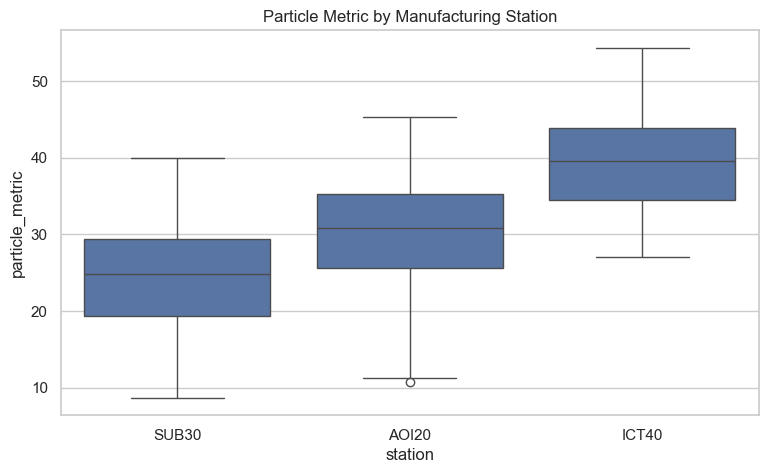

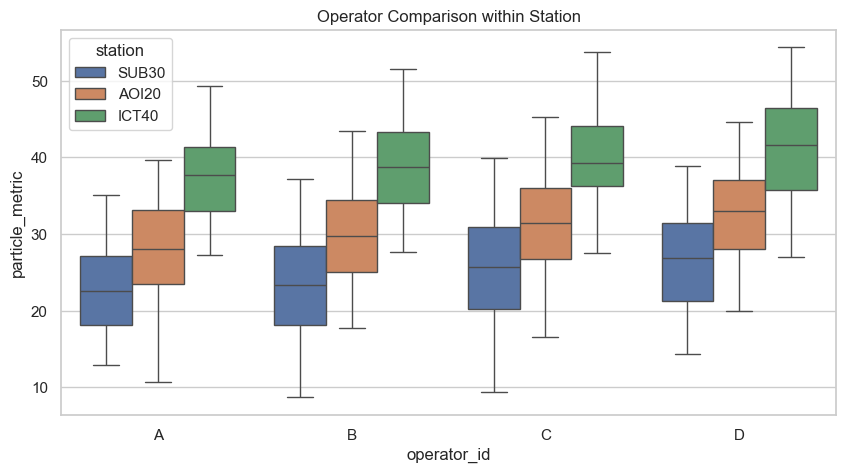

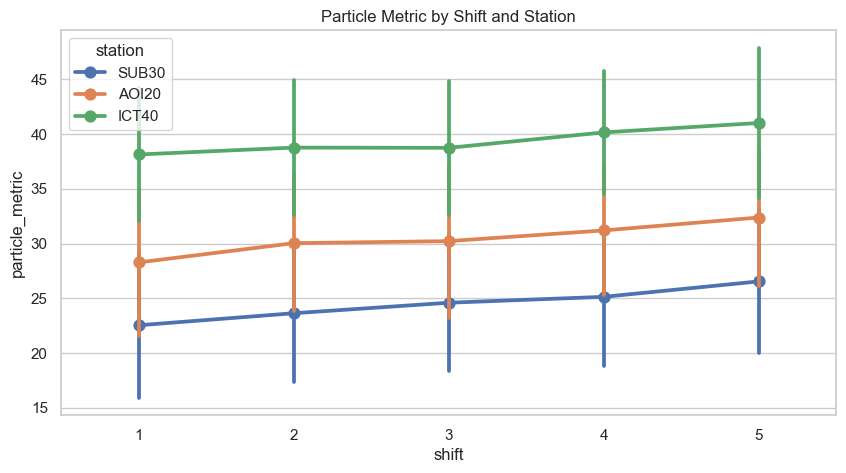

In [7]:
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=particles, x="station", y="particle_metric", ax=ax)
ax.set_title("Particle Metric by Manufacturing Station")
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=particles, x="operator_id", y="particle_metric", hue="station", ax=ax)
ax.set_title("Operator Comparison within Station")
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
sns.pointplot(data=particles, x="shift", y="particle_metric", hue="station", errorbar="sd", ax=ax)
ax.set_title("Particle Metric by Shift and Station")
plt.show()

# 9. Particle-size distribution

Particle counts can look acceptable even when the process generates larger particles, so this section examines the continuous size distribution.

Comparisons include:
- Metallic and Non-metallic particles;
- Line_A and Line_B; and
- differences by station.

The histograms show the particle sizes being generated and how their distributions vary. The particle metric combines size and count information into a broader contamination score.

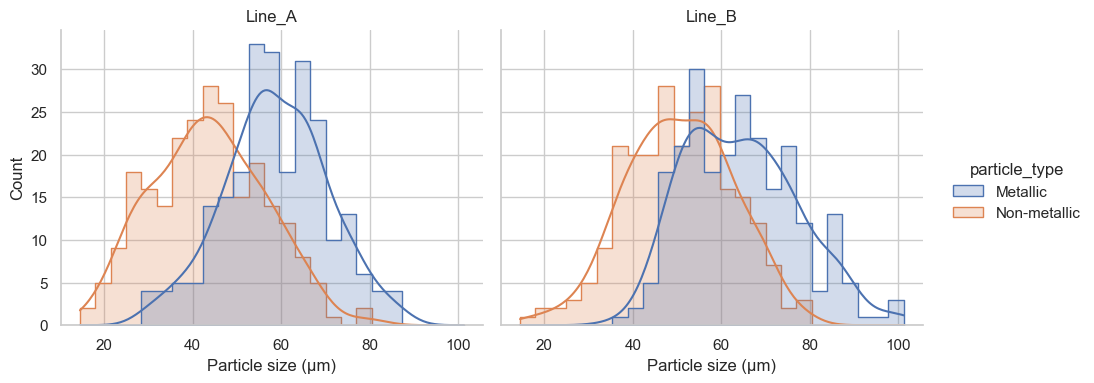

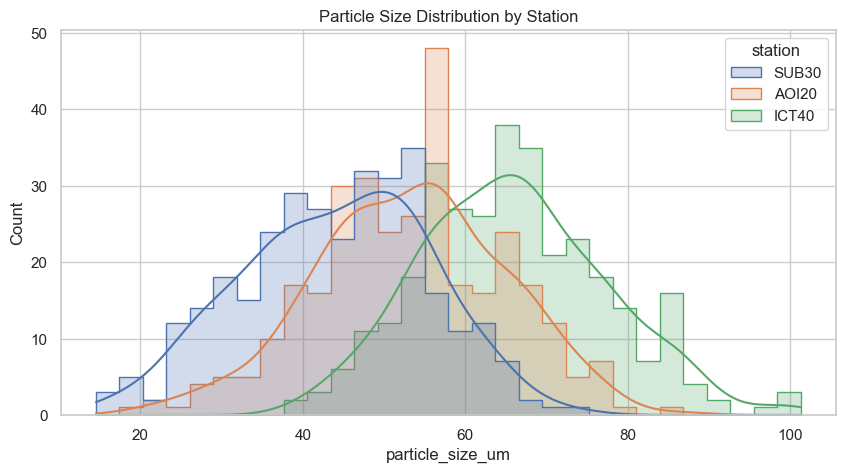

In [8]:
g = sns.displot(
    data=particles,
    x="particle_size_um",
    hue="particle_type",
    col="product_line",
    kind="hist",
    bins=25,
    kde=True,
    element="step",
    height=4,
    aspect=1.2
)
g.set_axis_labels("Particle size (µm)", "Count")
g.set_titles("{col_name}")
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(data=particles, x="particle_size_um", hue="station", bins=30, kde=True, element="step", ax=ax)
ax.set_title("Particle Size Distribution by Station")
plt.show()

# 10. Product-line and particle-type drill-down

The product-line comparison helps assess whether a station pattern could reflect product mix. The particle-type comparison assesses whether metallic particles differ systematically in size or contamination burden.

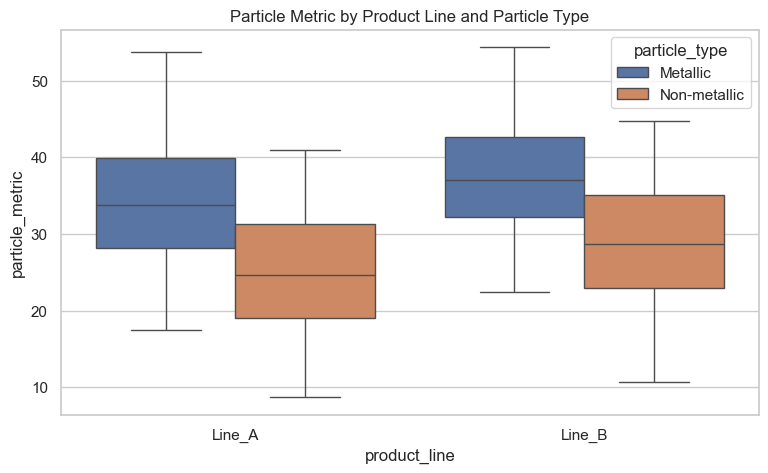

n  mean_size_um  mean_count  mean_metric  \
product_line particle_type                                               
Line_A       Metallic       240         58.84       24.50        34.11   
             Non-metallic   240         43.62       20.01        25.04   
Line_B       Metallic       240         64.53       27.44        37.63   
             Non-metallic   240         50.63       22.81        28.90   

                            mean_irr  
product_line particle_type            
Line_A       Metallic          96.61  
             Non-metallic      89.83  
Line_B       Metallic         101.24  
             Non-metallic      94.52

In [9]:
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=particles, x="product_line", y="particle_metric", hue="particle_type", ax=ax)
ax.set_title("Particle Metric by Product Line and Particle Type")
plt.show()

display(particles.groupby(["product_line","particle_type"]).agg(
    n=("sample_id","size"),
    mean_size_um=("particle_size_um","mean"),
    mean_count=("particle_count","mean"),
    mean_metric=("particle_metric","mean"),
    mean_irr=("irr","mean")
).round(2))

# 11. Questions to test

At this stage, use the charts to form hypotheses rather than draw conclusions:
- ICT40 appears higher: does the station pattern remain after accounting for operator, shift, product, and particle type?
- Some operators appear higher: is this an operator pattern, or are they more exposed to a high-contamination station or product?
- Shift 5 appears elevated: is this consistent across stations?
- Metallic particles appear larger: is the difference statistically supported?
- Line_B appears elevated: does product line remain important in a multivariable model?

The next section combines simple hypothesis tests with a multivariable model.

# 12. Statistical analysis

## 12.1 Compare stations

First, test whether mean particle metrics differ across stations:
- H0: mean particle metric is equal across SUB30, AOI20, and ICT40.
- H1: at least one station mean differs.

Levene's test assesses equality of variances. ANOVA evaluates the overall mean difference, and Tukey's test identifies which station pairs differ.

In [10]:
station_groups=[g["particle_metric"].to_numpy() for _,g in particles.groupby("station")]
levene_station=stats.levene(*station_groups, center="median")
anova_station=stats.f_oneway(*station_groups)
tukey_station=pairwise_tukeyhsd(particles["particle_metric"], particles["station"], alpha=ALPHA)
print("Levene:", levene_station)
print("ANOVA:", anova_station)
print(tukey_station)

Levene: LeveneResult(statistic=0.6549352841628235, pvalue=0.5197083556162418)
ANOVA: F_onewayResult(statistic=434.86335452831673, pvalue=4.5243353884874936e-135)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
 AOI20  ICT40   8.9366   0.0   7.7451   10.128   True
 AOI20  SUB30  -5.9318   0.0  -7.1233  -4.7404   True
 ICT40  SUB30 -14.8684   0.0 -16.0599 -13.6769   True
-----------------------------------------------------


Levene's test gives p = 0.520, so these data do not provide evidence that station variances differ. This supports using the classical one-way ANOVA for the station comparison.

The station ANOVA gives F = 434.86 and p = 4.52e-135.

The differences between SUB30, AOI20, and ICT40 are much larger than would be expected from within-station variation alone.

Mean particle metric:
- SUB30: 24.49
- AOI20: 30.42
- ICT40: 39.36

Tukey's HSD confirms that all three station pairs differ statistically. ICT40 has the highest average particle metric, making it a priority for engineering investigation. This is strong evidence for prioritization, but it does not prove that the station itself is the physical root cause.

## 12.2 Compare operators

A simple operator ANOVA is useful descriptively, but it can be misleading because operators may work under different station, product, or shift conditions. Treat it as an initial screen and rely on the adjusted multivariable model for the comparison that accounts for those factors.

In [11]:
operator_groups=[g["particle_metric"].to_numpy() for _,g in particles.groupby("operator_id")]
anova_operator=stats.f_oneway(*operator_groups)
print("Operator ANOVA:", anova_operator)

Operator ANOVA: F_onewayResult(statistic=9.399204631039671, pvalue=3.992370677036499e-06)


The operator ANOVA gives F = 9.40 and p = 3.99e-6. Unadjusted mean particle metrics range from 29.30 for Operator A to 33.34 for Operator D.

Operator groups are associated with different particle levels. However, this should not be interpreted as evidence that Operator D causes contamination: operators may be assigned disproportionately to particular stations, shifts, or product lines.

## 12.3 Compare shifts

Shift is treated as a categorical process condition because the relationship does not have to be linear from shift 1 to shift 5.

In [12]:
shift_groups=[g["particle_metric"].to_numpy() for _,g in particles.groupby("shift")]
anova_shift=stats.f_oneway(*shift_groups)
print("Shift ANOVA:", anova_shift)

Shift ANOVA: F_onewayResult(statistic=4.766125426029794, pvalue=0.0008236345692006451)


The shift ANOVA gives F = 4.77 and p = 0.000824. Average particle metric ranges from approximately 29.65 in the lowest shift group to 33.31 in the highest.

Shift is statistically associated with particle variation. Engineering follow-up should connect shifts to real clock time, cleaning cycles, maintenance, environmental conditions, material lots, and production volume before attributing a physical cause.

## 12.4 Compare product lines and particle types

Each comparison has two independent groups, so Welch's t-test is used without assuming equal variances.

In [13]:
line_a=particles.loc[particles.product_line=="Line_A","particle_metric"]
line_b=particles.loc[particles.product_line=="Line_B","particle_metric"]
welch_product=stats.ttest_ind(line_a,line_b,equal_var=False)

metal=particles.loc[particles.particle_type=="Metallic","particle_size_um"]
nonmetal=particles.loc[particles.particle_type=="Non-metallic","particle_size_um"]
welch_type_size=stats.ttest_ind(metal,nonmetal,equal_var=False)

print("Product-line Welch t-test:", welch_product)
print("Particle-size Metallic vs Non-metallic Welch t-test:", welch_type_size)

Product-line Welch t-test: TtestResult(statistic=-6.592544151835479, pvalue=7.132073268191673e-11, df=957.8926943365548)
Particle-size Metallic vs Non-metallic Welch t-test: TtestResult(statistic=17.81312400303273, pvalue=1.593009367647976e-61, df=957.2879719102606)


The product-line Welch test gives p = 7.13e-11. Mean particle metric is 29.58 for Line_A and 33.27 for Line_B.

The comparison of particle size by type gives p = 1.59e-61. Metallic particles average 61.7 um, compared with 47.1 um for Non-metallic particles.

The contamination profile should not be reduced to particle count alone. Product line, particle type, and size distribution provide additional information about potential contamination mechanisms.

## 12.5 Adjusted multi-factor model

This is the key statistical step for the expanded problem. A multiple linear model estimates each factor's association with `particle_metric` while holding the other included factors constant.

Model:

`particle_metric ~ station + operator_id + shift + product_line + particle_type + particle_size_um`

This model does not make observational data causal evidence. It is stronger than comparing each factor independently because it accounts for the other recorded dimensions and reduces obvious confounding.

In [14]:
model = smf.ols(
    "particle_metric ~ C(station) + C(operator_id) + C(shift) + C(product_line) + C(particle_type) + particle_size_um",
    data=particles
).fit()

anova_adjusted = anova_lm(model, typ=2)
display(anova_adjusted)
print(model.summary())

,sum_sq,df,F,PR(>F)
C(station),11033.178986,2.0,417.274711,1.119235e-130
C(operator_id),2055.603520,3.0,51.828602,5.081300e-31
C(shift),1278.008167,4.0,24.167128,4.614950e-19
C(product_line),1761.822116,1.0,133.264187,6.167873e-29
C(particle_type),6800.498394,1.0,514.389553,2.658053e-91
particle_size_um,1007.752428,1.0,76.226372,1.127655e-17
Residual,12519.834321,947.0,NaN,NaN


                            OLS Regression Results                            
Dep. Variable:        particle_metric   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     395.7
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:55:38   Log-Likelihood:                -2594.9
No. Observations:                 960   AIC:                             5216.
Df Residuals:                     947   BIC:                             5279.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In the model of `particle_metric` against station, operator, shift, product line, particle type, and particle size, all included factors remain statistically associated at alpha = 0.05:
- station;
- operator;
- shift;
- product line;
- particle type; and
- particle size.

This reduces the risk of drawing conclusions from a single unadjusted box plot. For example, the station pattern remains visible when the other recorded factors are included in the same model.

This is still observational modeling. A statistically significant adjusted coefficient is evidence of an association conditional on the variables in the model, not experimental proof of causality.

## 12.6 Particle metric and IRR

Examine the relationship after analyzing the process factors:
- Pearson correlation measures linear association.
- Spearman correlation measures monotonic rank association.

Neither test proves that particles cause IRR.

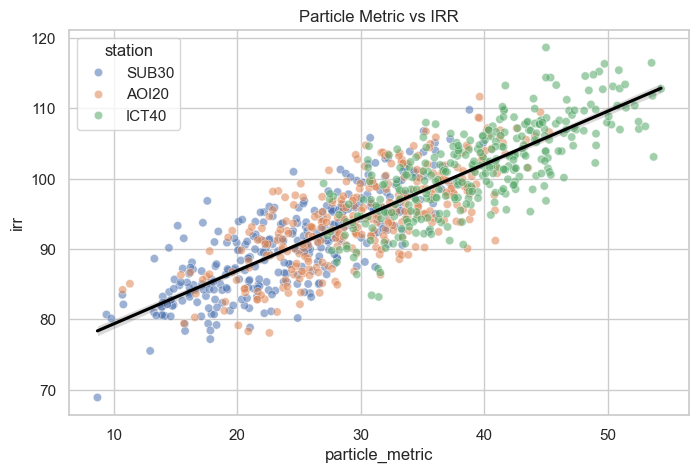

Pearson r=0.852, p=6.032e-271
Spearman rho=0.846, p=4.012e-264


In [15]:
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=particles, x="particle_metric", y="irr", hue="station", alpha=.55, ax=ax)
sns.regplot(data=particles, x="particle_metric", y="irr", scatter=False, color="black", ax=ax)
ax.set_title("Particle Metric vs IRR")
plt.show()

pearson_r, pearson_p=stats.pearsonr(particles["particle_metric"],particles["irr"])
spearman_r, spearman_p=stats.spearmanr(particles["particle_metric"],particles["irr"])
print(f"Pearson r={pearson_r:.3f}, p={pearson_p:.4g}")
print(f"Spearman rho={spearman_r:.3f}, p={spearman_p:.4g}")

Pearson correlation is r = 0.852 and Spearman correlation is rho = 0.846; both have very small p-values.

Particle metric and IRR have a strong positive relationship in this dataset. The similar Pearson and Spearman values indicate that the association is not simply an artifact of a few extreme observations. Higher particle metrics tend to occur alongside higher IRR.

This does not prove that an increase in particle metric causes the IRR response. A controlled intervention or designed experiment would be needed to support a causal claim.

# 13. Statistical conclusions

The conclusions should distinguish three levels of evidence:
- Descriptive evidence: visible differences in charts and gold tables.
- Inferential evidence: ANOVA, Welch tests, and the multivariable model.
- Causal evidence: not established by this observational dataset.

In [16]:
# Convert adjusted ANOVA table to a dashboard-friendly table.
adj = anova_adjusted.reset_index().rename(columns={"index":"factor","PR(>F)":"p_value","F":"statistic"})
adj["analysis"]="Adjusted OLS Type-II ANOVA"
adj_out=adj[["analysis","factor","statistic","p_value"]].copy()

python_stats = pd.DataFrame([
    {"analysis":"Levene across stations","factor":"station","statistic":levene_station.statistic,"p_value":levene_station.pvalue},
    {"analysis":"One-way ANOVA across stations","factor":"station","statistic":anova_station.statistic,"p_value":anova_station.pvalue},
    {"analysis":"One-way ANOVA across operators","factor":"operator_id","statistic":anova_operator.statistic,"p_value":anova_operator.pvalue},
    {"analysis":"One-way ANOVA across shifts","factor":"shift","statistic":anova_shift.statistic,"p_value":anova_shift.pvalue},
    {"analysis":"Welch product-line comparison","factor":"product_line","statistic":welch_product.statistic,"p_value":welch_product.pvalue},
    {"analysis":"Welch particle-size type comparison","factor":"particle_type","statistic":welch_type_size.statistic,"p_value":welch_type_size.pvalue},
    {"analysis":"Pearson metric vs IRR","factor":"particle_metric","statistic":pearson_r,"p_value":pearson_p},
    {"analysis":"Spearman metric vs IRR","factor":"particle_metric","statistic":spearman_r,"p_value":spearman_p},
])
python_stats=pd.concat([python_stats,adj_out],ignore_index=True)

with sqlite3.connect(DB_PATH) as con:
    python_stats.to_sql("gold_python_statistics",con,if_exists="replace",index=False)
    pd.DataFrame({
        "term":model.params.index,
        "coefficient":model.params.values,
        "p_value":model.pvalues.values,
        "ci_low":model.conf_int()[0].values,
        "ci_high":model.conf_int()[1].values,
    }).to_sql("gold_adjusted_model_coefficients",con,if_exists="replace",index=False)

display(python_stats.head(20))

,analysis,factor,statistic,p_value
0,Levene across stations,station,0.654935,5.197084e-01
1,One-way ANOVA across stations,station,434.863355,4.524335e-135
2,One-way ANOVA across operators,operator_id,9.399205,3.992371e-06
3,One-way ANOVA across shifts,shift,4.766125,8.236346e-04
4,Welch product-line comparison,product_line,-6.592544,7.132073e-11
5,Welch particle-size type comparison,particle_type,17.813124,1.593009e-61
6,Pearson metric vs IRR,particle_metric,0.851578,6.032089e-271
7,Spearman metric vs IRR,particle_metric,0.846184,4.012176e-264
8,Adjusted OLS Type-II ANOVA,C(station),417.274711,1.119235e-130
9,Adjusted OLS Type-II ANOVA,C(operator_id),51.828602,5.081300e-31


-----

# 14. Additional SQL questions

After visual and statistical analysis identifies the dominant patterns, SQL turns those findings into repeatable analytical queries and database tables.

## Which individual records have an above-average particle metric and are either large (>= 60 um) or metallic?

In [17]:
sql_question1 = """
SELECT
    sample_id,
    station,
    operator_id,
    shift,
    product_line,
    particle_type,
    particle_size_um,
    particle_metric,
    irr
FROM silver_particles_irr
WHERE particle_metric > (
    SELECT AVG(particle_metric)
    FROM silver_particles_irr
)
    AND (
        particle_size_um >= 60
        OR particle_type = 'Metallic'
    )
ORDER BY particle_metric DESC;
"""

with sqlite3.connect(DB_PATH) as con:
    question_1 = pd.read_sql_query(sql_question1, con)
    
print("Rows isolated:", len(question_1))
display(question_1.head(15))

Rows isolated: 399


,sample_id,station,operator_id,shift,product_line,particle_type,particle_size_um,particle_metric,irr
0,923,ICT40,D,3,Line_B,Metallic,97.33,54.33,112.77
1,867,ICT40,C,5,Line_A,Metallic,75.38,53.73,103.10
2,956,ICT40,D,5,Line_B,Metallic,85.35,53.64,111.78
3,826,ICT40,C,2,Line_B,Metallic,79.68,53.56,116.47
4,892,ICT40,D,1,Line_B,Metallic,86.74,53.06,107.44
5,876,ICT40,C,5,Line_B,Metallic,75.13,52.53,107.06
6,907,ICT40,D,2,Line_B,Metallic,74.46,52.51,108.10
7,955,ICT40,D,5,Line_B,Metallic,76.67,52.20,110.38
8,786,ICT40,B,5,Line_A,Metallic,69.59,51.49,110.09
9,875,ICT40,C,5,Line_B,Metallic,85.73,51.42,113.40


This is a record-level screening step. It does not prove that the selected records are defects or root causes; it creates a focused population for engineering review. The query first isolates observations that meet a condition, before any grouped metrics are calculated.

## Which station, operator, and shift combinations have enough observations and an average particle metric above the overall process average?

In [18]:
sql_question2 = """
SELECT
    station,
    operator_id,
    shift,
    COUNT(*) as n,
    AVG(particle_metric) as avg_particle_metric,
    AVG(particle_size_um) as avg_particle_size_um,
    AVG(irr) as avg_irr
FROM silver_particles_irr
GROUP BY station, operator_id, shift
HAVING COUNT(*) >= 10
    AND AVG(particle_metric) > 
        (SELECT AVG(particle_metric) FROM silver_particles_irr)
ORDER BY avg_particle_metric DESC;
"""

with sqlite3.connect(DB_PATH) as con:
    question_2 = pd.read_sql_query(sql_question2, con)
    
display(question_2)

,station,operator_id,shift,n,avg_particle_metric,avg_particle_size_um,avg_irr
0,ICT40,C,5,16,43.349375,68.623125,103.513750
1,ICT40,D,4,16,43.040625,67.206875,103.518750
2,ICT40,D,5,16,41.187500,68.411250,103.213750
3,ICT40,D,2,16,40.972500,66.098125,103.960000
4,ICT40,D,1,16,40.842500,66.576250,99.923750
5,ICT40,C,4,16,40.400625,68.251250,103.580625
6,ICT40,B,5,16,40.305000,69.272500,101.706875
7,ICT40,D,3,16,40.108750,64.072500,102.069375
8,ICT40,B,3,16,39.750625,64.638750,100.210625
9,ICT40,B,4,16,39.252500,64.136875,100.916250


This identifies station/operator/shift groups whose average particle metric is above the process average. `HAVING` turns the broad statistical finding into an operational drill-down.

## For each station, how does the current particle metric compare with the previous and next recorded observations?

Change from the previous observation: `Delta_t = x_t - x_(t-1)`.

`LAG` retrieves the previous value. Partitioning by station resets the sequence for each manufacturing station, while ordering by `sample_id` defines the sequence within each station.

In [19]:
sql_question3 = """
SELECT
    sample_id,
    station,
    particle_metric,

    LAG(particle_metric) OVER (
        PARTITION BY station
        ORDER BY sample_id
    ) AS previous_particle_metric,

    LEAD(particle_metric) OVER (
        PARTITION BY station
        ORDER BY sample_id
    ) AS next_particle_metric,

    particle_metric -
    LAG(particle_metric) OVER (
        PARTITION BY station
        ORDER BY sample_id
    ) AS change_from_previous,

    LEAD(particle_metric) OVER (
        PARTITION BY station
        ORDER BY sample_id
    ) - particle_metric AS change_to_next

FROM silver_particles_irr
ORDER BY station, sample_id;
"""

with sqlite3.connect(DB_PATH) as con:
    question3 = pd.read_sql_query(sql_question3, con)
    
display(question3.head(20))

,sample_id,station,particle_metric,previous_particle_metric,next_particle_metric,change_from_previous,change_to_next
0,321,AOI20,20.33,NaN,28.28,NaN,7.95
1,322,AOI20,28.28,20.33,34.66,7.95,6.38
2,323,AOI20,34.66,28.28,23.35,6.38,-11.31
3,324,AOI20,23.35,34.66,15.70,-11.31,-7.65
4,325,AOI20,15.70,23.35,16.20,-7.65,0.50
5,326,AOI20,16.20,15.70,11.31,0.50,-4.89
6,327,AOI20,11.31,16.20,15.44,-4.89,4.13
7,328,AOI20,15.44,11.31,35.28,4.13,19.84
8,329,AOI20,35.28,15.44,32.48,19.84,-2.80
9,330,AOI20,32.48,35.28,31.25,-2.80,-1.23


`LAG` and `LEAD` preserve the row-level detail while they help to:
- detect sudden increases or decreases;
- compare consecutive measurements;
- create change variables; and
- demonstrate sequence-based monitoring logic.

The sample order is not a real production timeline because the source CSV contains no production timestamps.

-----

# 15. Final project conclusions

## What the data shows

1. **Station is the dominant process segmentation:** mean particle metric is approximately 24.49 at SUB30, 30.42 at AOI20, and 39.36 at ICT40. The station ANOVA gives p = 4.52e-135, and Tukey's test indicates that all station pairs differ.
2. **Operator is associated with particle level:** the unadjusted ANOVA gives p = 3.99e-6, but operator assignment may be confounded with station, shift, and product.
3. **Shift is associated with particle variation:** ANOVA gives p = 0.000824. This supports collecting real timestamps and linking process data to cleaning, maintenance, and environmental events.
4. **Product line matters:** Line_A and Line_B differ in particle metric (Welch p = 7.13e-11).
5. **Particle type and size matter:** metallic particles average about 61.7 um, versus 47.1 um for non-metallic particles.
6. **Particle metric is strongly associated with IRR:** Pearson r = 0.852 and Spearman rho = 0.846.
7. In the adjusted multi-factor model, station, operator, shift, product line, particle type, and particle size remain statistically associated with particle metric.

## What the analysis does not prove

This is observational training data. Statistical significance and adjusted regression do not prove a physical causal mechanism. The analysis cannot establish that ICT40, an operator, a shift, or a particle type causes IRR.

## Problem-solving conclusion

The evidence supports prioritizing ICT40 for engineering investigation while controlling for operator, shift, product line, particle type, and size. The strongest next step is to collect better process context and conduct controlled validation, rather than simply calculate another p-value.

## Next steps

1. Add defect or rejection categories and connect particle exposure to cosmetic, insulation, or short-circuit defects.
2. Add cleaning, maintenance, material-lot, and product-change events.
3. Validate the particle classification and measurement system with a measurement systems analysis (MSA).
4. Investigate particle source and composition, especially for metallic particles.
5. Run controlled before-and-after trials at the station of greatest concern.
6. If feasible, design an experiment (DOE) to separate station and process-condition effects.

----

# 16. Streamlit dashboard

The dashboard uses:
- silver sample-level data;
- gold SQL summaries;
- Python statistical results; and
- adjusted-model coefficients.

It supports filtering by station, operator, shift, product line, particle type, and size band, and includes a dedicated particle-size histogram.

**Run the dashboard**

```bash
streamlit run particles_irr_streamlit.py
```